<a href="https://colab.research.google.com/github/boba-frog/Fraud-Detection/blob/main/Linear_SVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your CSV file on Google Drive
file_path = '/content/drive/MyDrive/DATASET/financial_fraud_detection_dataset.csv' # Replace with the actual path

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print("DataFrame loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Mounted at /content/drive
DataFrame loaded successfully!
  transaction_id                   timestamp sender_account receiver_account  \
0        T100000  2023-08-22T09:22:43.516168      ACC877572        ACC388389   
1        T100001  2023-08-04T01:58:02.606711      ACC895667        ACC944962   
2        T100002  2023-05-12T11:39:33.742963      ACC733052        ACC377370   
3        T100003  2023-10-10T06:04:43.195112      ACC996865        ACC344098   
4        T100004  2023-09-24T08:09:02.700162      ACC584714        ACC497887   

    amount transaction_type merchant_category location device_used  is_fraud  \
0   343.78       withdrawal         utilities    Tokyo      mobile     False   
1   419.65       withdrawal            online  Toronto         atm     False   
2  2773.86          deposit             other   London         pos     False   
3  1666.22          deposit            online   Sydney         pos     False   
4    24.43         transfer         utilities  Toronto      mo

In [ ]:
#ENCODING PT1
#Configuring the variables for Machine Learning.
# Categorical columns identified from the previous step:
# ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'fraud_type', 'payment_channel', 'ip_address', 'device_hash']

# Plan for encoding categorical columns:
# transaction_id: High cardinality, likely not useful as a direct feature. Consider dropping or using feature engineering if needed. For this task, we'll plan to drop it.
# timestamp: Time-series data. Requires specific handling (e.g., extracting features like hour, day of week). For this task, we'll plan to drop it for simplicity in this subtask.
# sender_account, receiver_account: High cardinality, likely not useful as direct features. Consider dropping or using feature engineering (e.g., aggregation). For this task, we'll plan to drop them.
# transaction_type: Low cardinality, nominal. Use one-hot encoding.
# merchant_category: Moderate cardinality, nominal. Use one-hot encoding.
# location: High cardinality. Consider dropping or using feature engineering. For this task, we'll plan to drop it.
# device_used: Moderate cardinality, nominal. Use one-hot encoding.
# is_fraud: Target variable (boolean). Can be treated as 0/1 for classification. No encoding needed for the target variable itself, but it's important to identify it.
# fraud_type: Moderate cardinality, nominal. Use one-hot encoding.
# payment_channel: Low cardinality, nominal. Use one-hot encoding.
# ip_address: High cardinality, likely not useful as a direct feature. Consider dropping or using feature engineering. For this task, we'll plan to drop it.
# device_hash: High cardinality, likely not useful as a direct feature. Consider dropping or using feature engineering. For this task, we'll plan to drop it.

# Columns to drop due to high cardinality or irrelevance for direct encoding:
cols_to_drop = ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'location', 'ip_address', 'device_hash']

# Columns for one-hot encoding:
cols_for_onehot = ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel']

# Target variable (no encoding needed for the variable itself):
target_col = 'is_fraud'

print("Plan for encoding categorical variables:")
print(f"Columns to be dropped: {cols_to_drop}")
print(f"Columns for one-hot encoding: {cols_for_onehot}")
print(f"Target variable: {target_col}")

Plan for encoding categorical variables:
Columns to be dropped: ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'location', 'ip_address', 'device_hash']
Columns for one-hot encoding: ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel']
Target variable: is_fraud


In [ ]:
#ENCODING PT2
# Converting USEFUL columns into usable data.
# Drop the columns identified for dropping
df_encoded = df.drop(columns=cols_to_drop)

# Apply one-hot encoding to the columns identified for one-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=cols_for_onehot, drop_first=True)

# Display the first few rows of the encoded DataFrame to verify
print("DataFrame after dropping and one-hot encoding:")
display(df_encoded.head())

# Display the data types of the encoded DataFrame to verify
print("\nData types of the encoded DataFrame:")
print(df_encoded.dtypes)

DataFrame after dropping and one-hot encoding:


,amount,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,transaction_type_payment,transaction_type_transfer,transaction_type_withdrawal,merchant_category_grocery,...,merchant_category_restaurant,merchant_category_retail,merchant_category_travel,merchant_category_utilities,device_used_mobile,device_used_pos,device_used_web,payment_channel_UPI,payment_channel_card,payment_channel_wire_transfer
0,343.78,False,NaN,-0.21,3,0.22,False,False,True,False,...,False,False,False,True,True,False,False,False,True,False
1,419.65,False,NaN,-0.14,7,0.96,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,2773.86,False,NaN,-1.78,20,0.89,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,1666.22,False,NaN,-0.60,6,0.37,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
4,24.43,False,NaN,0.79,13,0.27,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False



Data types of the encoded DataFrame:
amount                           float64
is_fraud                            bool
time_since_last_transaction      float64
spending_deviation_score         float64
velocity_score                     int64
geo_anomaly_score                float64
transaction_type_payment            bool
transaction_type_transfer           bool
transaction_type_withdrawal         bool
merchant_category_grocery           bool
merchant_category_online            bool
merchant_category_other             bool
merchant_category_restaurant        bool
merchant_category_retail            bool
merchant_category_travel            bool
merchant_category_utilities         bool
device_used_mobile                  bool
device_used_pos                     bool
device_used_web                     bool
payment_channel_UPI                 bool
payment_channel_card                bool
payment_channel_wire_transfer       bool
dtype: object


In [ ]:
!pip install imbalanced-learn

Original dataset shape: Counter({False: 4820447, True: 179553})
Sampled training dataset shape before SMOTE: Counter({False: 385636, True: 14364})
Resampled dataset shape after SMOTE: Counter({False: 385636, True: 385636})

=== Best F1 ===
Threshold: -2.9632
F1 = 0.0693
Confusion Matrix:
[[  1358 962731]
 [    42  35869]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.00      0.00    964089
        True       0.04      1.00      0.07     35911

    accuracy                           0.04   1000000
   macro avg       0.50      0.50      0.04   1000000
weighted avg       0.94      0.04      0.01   1000000


=== Recall>=70% ===
Threshold: -0.9807
Precision = 0.0360, Recall = 0.7102
Confusion Matrix:
[[280194 683895]
 [ 10406  25505]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.29      0.45    964089
        True       0.04      0.71      0.07     35911

    accura

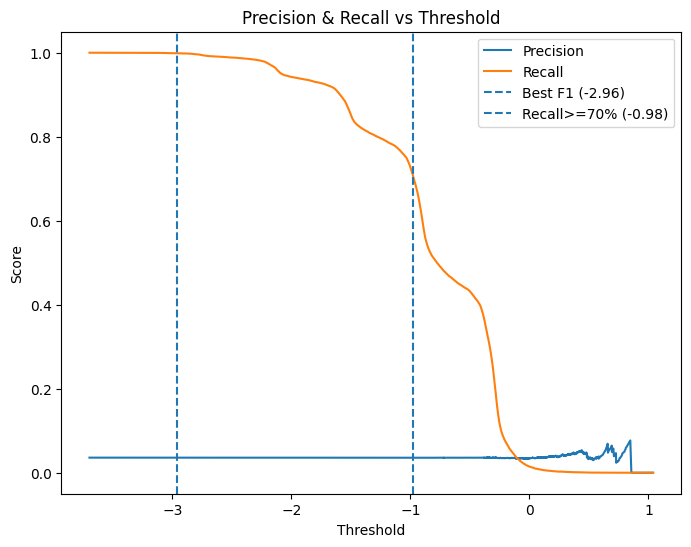

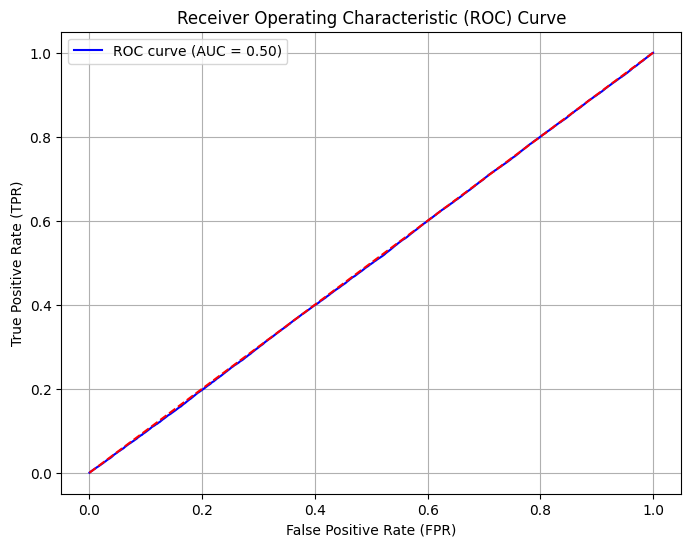

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC # Import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------
# Data prep
# -----------------------
# Data prep - X and y from the encoded DataFrame
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

# Impute missing values
X['time_since_last_transaction'] = X['time_since_last_transaction'].fillna(
    X['time_since_last_transaction'].mean()
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Sample a smaller portion of the training data for SMOTE to speed up processing
X_train_sampled, _, y_train_sampled, _ = train_test_split(
    X_train, y_train, test_size=0.9, random_state=42, stratify=y_train
)

# Apply SMOTE to the sampled training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sampled, y_train_sampled)

print(f"Original dataset shape: {Counter(y)}")
print(f"Sampled training dataset shape before SMOTE: {Counter(y_train_sampled)}")
print(f"Resampled dataset shape after SMOTE: {Counter(y_train_res)}")

# -----------------------
# Feature Scaling
# -----------------------
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# -----------------------
# Train model
# -----------------------
# Setting dual=False is preferred when n_samples > n_features and helps convergence
model = LinearSVC(random_state=42, dual=False, max_iter=5000)
model.fit(X_train_res_scaled, y_train_res)

# -----------------------
# Threshold tuning
# -----------------------
y_scores = model.decision_function(X_test_small)
y_test = y_test_small
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Store candidate thresholds
best_results = {
    "Best F1": {"threshold": 0.0, "f1": 0},
    "Recall>=70%": {"threshold": None, "precision": 0},
    "Precision>=10%": {"threshold": None, "recall": 0}
}

# Optimized loop: check every 50th threshold for speed
for i in range(0, len(thresholds), 50):
    p = precision[i]
    r = recall[i]
    t = thresholds[i]

    y_pred_t = (y_scores >= t).astype(int)

    f1 = f1_score(y_test, y_pred_t, pos_label=1)
    if f1 > best_results["Best F1"]["f1"]:
        best_results["Best F1"] = {"threshold": t, "f1": f1}

    if r >= 0.70 and p > best_results["Recall>=70%"]["precision"]:
        best_results["Recall>=70%"] = {"threshold": t, "precision": p, "recall": r}

    if p >= 0.10 and r > best_results["Precision>=10%"]["recall"]:
        best_results["Precision>=10%"] = {"threshold": t, "precision": p, "recall": r}

# -----------------------
# Print results
# -----------------------
for name, result in best_results.items():
    if result["threshold"] is None:
        print(f"\n{name}: No valid threshold found")
        continue

    t = result["threshold"]
    y_pred_t = (y_scores >= t).astype(int)

    print(f"\n=== {name} ===")
    print(f"Threshold: {t:.4f}")
    if "f1" in result:
        print(f"F1 = {result['f1']:.4f}")
    if "precision" in result:
        print(f"Precision = {result['precision']:.4f}, Recall = {result['recall']:.4f}")

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_t))
    print("Classification Report:")
    print(classification_report(y_test, y_pred_t))

# -----------------------
# Plots
# -----------------------
plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
for name, result in best_results.items():
    if result["threshold"] is not None:
        plt.axvline(result["threshold"], linestyle="--", label=f"{name} ({result['threshold']:.2f})")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.show()

fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()